<h1><strong>What is univariate imputation?</strong></h1>

Univariate imputation is a method where we fill missing values in specific column based solely on the statistics of that column (eg. mean,median,mode), We do not look at other variables in the dataset to make our guess.

<h3><strong>Numerical Features</strong></h3>

In [3]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 1.1 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 3.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [20]:
np.random.seed(42)

data = {
    'Age':np.round(np.random.normal(30,10,1000).tolist(),0),
    'Salary':np.random.exponential(50000,1000).tolist()
}
df = pd.DataFrame(data)

In [22]:
df.isnull().sum()

Age       0
Salary    0
dtype: int64

In [23]:
df.columns

Index(['Age', 'Salary'], dtype='object')

In [24]:
df.sample(frac=0.1).index

Index([861, 119, 560, 179, 674, 670, 590, 151, 789, 635, 288, 579, 594, 305,
       719, 412, 972, 607,   1, 351, 713, 705,  96, 199, 860, 441,  36,  59,
       130, 149, 819, 866, 525, 721, 341, 409, 859, 166, 184, 875, 984, 506,
       313, 909, 722, 414, 571, 157, 777, 405, 885, 540, 843, 942, 547, 830,
       471, 220, 999, 890, 749, 741, 787, 710, 237, 521, 129, 708, 456, 318,
        79, 462, 857, 848, 714, 990, 896, 150, 395, 143, 188, 517, 613, 191,
       269, 120, 845, 966, 109, 995, 352, 466, 461, 228, 820, 709, 801, 737,
       459, 253],
      dtype='int64')

In [25]:
for col in df.columns:
    df.loc[df.sample(frac=0.1).index,col] = np.nan

In [26]:
df.isnull().sum()

Age       100
Salary    100
dtype: int64

In [27]:
df.describe()

,Age,Salary
count,900.000000,900.000000
mean,30.051111,50330.638214
std,9.825148,50595.937818
min,-2.000000,161.172668
25%,23.000000,13792.570123
50%,30.000000,35751.649619
75%,36.000000,68968.257239
max,69.000000,372086.145485


In [28]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.1 MB 4.3 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 3.6 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 2.7 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


<h4>Filled with mean</h4>

In [30]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy='mean')

df['Age_mean'] = mean_imputer.fit_transform(df[['Age']])

In [50]:
df.isnull().sum()

Age              100
Salary           100
Age_mean           0
salary_median      0
dtype: int64

In [34]:
df.describe()

,Age,Salary,Age_mean
count,900.000000,900.000000,1000.000000
mean,30.051111,50330.638214,30.051111
std,9.825148,50595.937818,9.320436
min,-2.000000,161.172668,-2.000000
25%,23.000000,13792.570123,24.000000
50%,30.000000,35751.649619,30.051111
75%,36.000000,68968.257239,36.000000
max,69.000000,372086.145485,69.000000


In [35]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 1.7 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [37]:
import seaborn as sns

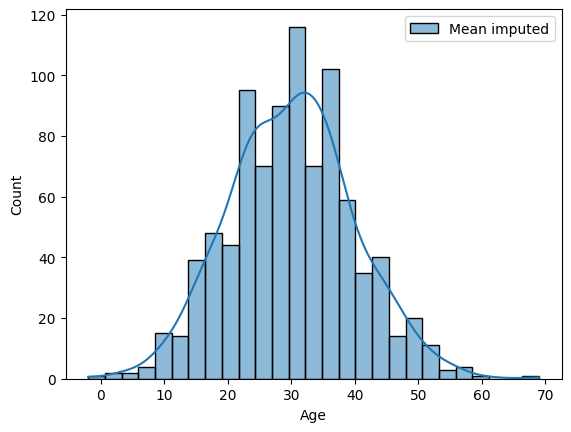

In [44]:
sns.histplot(df['Age'],label='Mean imputed',kde=True)
plt.legend()
plt.show()

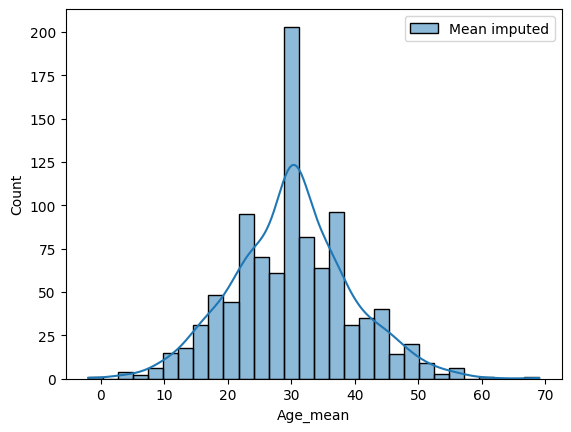

In [43]:
sns.histplot(df['Age_mean'],label='Mean imputed',kde=True)
plt.legend()
plt.show()

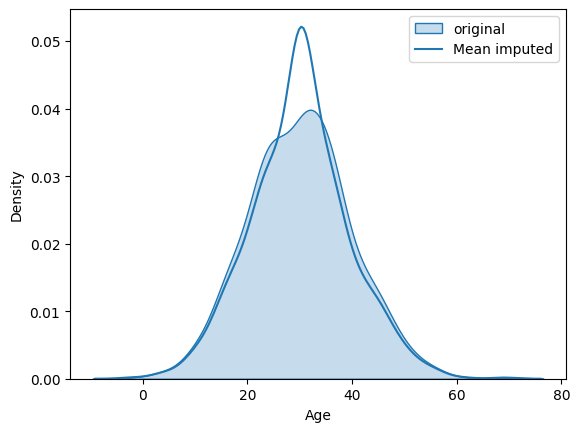

In [38]:
sns.kdeplot(df['Age'],label='original',fill=True)
sns.kdeplot(df['Age_mean'],label='Mean imputed')
plt.legend()
plt.show()

<h4>Filled with median</h4>

In [39]:
median_imputer = SimpleImputer(strategy='median')

df['salary_median'] = median_imputer.fit_transform(df[['Salary']])

df

,Age,Salary,Age_mean,salary_median
0,35.0,9165.056757,35.000000,9165.056757
1,29.0,5522.440864,29.000000,5522.440864
2,36.0,50589.205735,36.000000,50589.205735
3,45.0,61289.746976,45.000000,61289.746976
4,28.0,1604.787337,28.000000,1604.787337
...,...,...,...,...
995,27.0,16472.671396,27.000000,16472.671396
996,48.0,11596.134927,48.000000,11596.134927
997,36.0,36342.709466,36.000000,36342.709466
998,NaN,276.050597,30.051111,276.050597


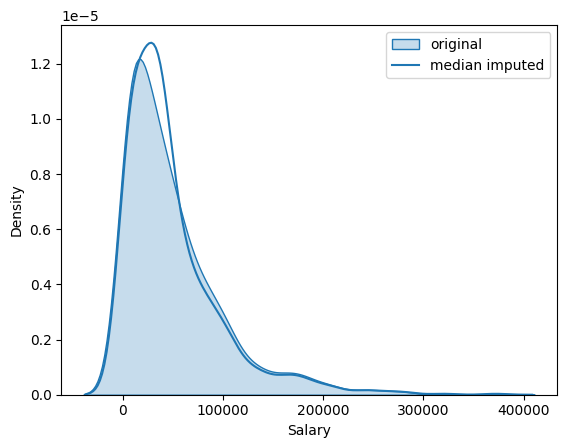

In [46]:
sns.kdeplot(df['Salary'],label='original',fill=True)
sns.kdeplot(df['salary_median'],label='median imputed')
plt.legend()
plt.show()

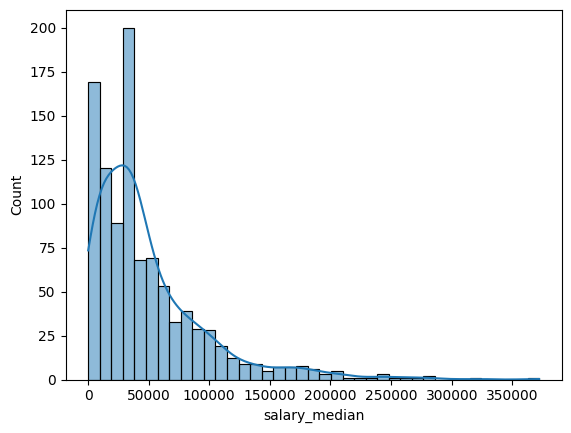

In [40]:
sns.histplot(df['salary_median'],kde=True)
plt.show()

Random value imputation

In [54]:
def random_value_imputation(series):
    data = series.copy()
    random_samples = data.dropna().sample(data.isnull().sum(),random_state=42)
    random_samples.index = data[data.isnull()].index
    data.loc[data.isnull()] = random_samples
    return data

In [55]:
df['Age_random'] = random_value_imputation(df['Age'])

In [56]:
df.isnull().sum()

Age              100
Salary           100
Age_mean           0
salary_median      0
Age_random         0
dtype: int64

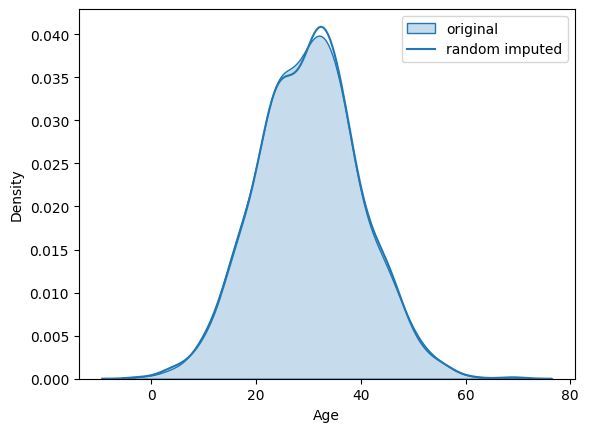

In [57]:
sns.kdeplot(df['Age'],label='original',fill=True)
sns.kdeplot(df['Age_random'],label='random imputed')
plt.legend()
plt.show()

End of Distribution Imputation

In [61]:
3 * df['Age'].std()

np.float64(29.47544442835707)

In [58]:
extreme = df['Age'].mean() + 3 * df['Age'].std()

df['EndDist'] = df['Age'].fillna(extreme)

In [60]:
extreme

np.float64(59.52655553946818)

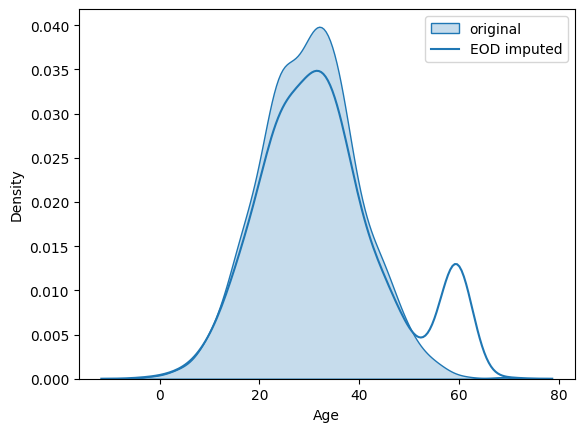

In [59]:
sns.kdeplot(df['Age'],label='original',fill=True)
sns.kdeplot(df['EndDist'],label='EOD imputed')
plt.legend()
plt.show()